# Set environment

In [28]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys

from scipy import interp

### import flowImg
py_path = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image"
sys.path.insert(0, py_path)
from flowImg import *
from flowImg_helper import *

### sklearn
from sklearn.metrics import roc_curve, auc, accuracy_score

### plot
import matplotlib.pyplot as plt
plt.style.use("seaborn-whitegrid")

### global const
SEED    = 123
DAT_DIR = "/data/clintko/flow_EQAPOL_normal/pipe01"
FIG_DIR = "/local_data/notebooks/clintko/GitRepo/Proj_Flow2Image/fig"

# Load data

In [2]:
!ls /data/clintko/flow_EQAPOL_normal/pipe01

model_vgg16_lr5e6_bs10_noBNorm.h5		 wrap01_data.P
model_vgg16_lr5e6_bs10_noBNorm_history.P	 wrap02_scaled_k0.P
model_vgg16_lr5e6_bs10_noBNorm.yaml		 wrap03_subs_1e4_N100.P
model_vgg16_lre5_bs10_noBNorm.h5		 wrap03_subs_1e4_N10.P
model_vgg16_noBNorm_lr5e6_bs10_SEB.h5		 wrap03_subs_1e4_N50.P
model_vgg16_noBNorm_lr5e6_bs10_SEB_history.P	 wrap04_tsne_1e4_N10.P
model_vgg16_noBNorm_lr5e6_bs10_SEB.yaml		 wrap04_tsne_1e4_N50.P
model_vgg16_noBNorm_lr5e6_bs50_class3.h5	 wrap05_img_1e4_N50_var01.P
model_vgg16_noBNorm_lr5e6_bs50_class3_history.P  wrap05_img_1e4_N50_var10.P
model_vgg16_noBNorm_lr5e6_bs50_class3.yaml	 wrap05_img_1e4_var01.P
model_vgg16_noBNorm_lr5e6_bs50_SEB.h5		 wrap05_img_1e4_var02.P
model_vgg16_noBNorm_lr5e6_bs50_SEB_history.P	 wrap05_img_1e4_var05.P
model_vgg16_noBNorm_lr5e6_bs50_SEB.yaml		 wrap05_img_1e4_var10.P


In [3]:
###
fname = "wrap05_img_1e4_var01.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_n10_v01 = pickle.load(file)
file.close()


In [4]:
###
fname = "wrap05_img_1e4_var02.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_n10_v02 = pickle.load(file)
file.close()

In [5]:
###
fname = "wrap05_img_1e4_var05.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_n10_v05 = pickle.load(file)
file.close()

In [6]:
###
fname = "wrap05_img_1e4_N50_var01.P"
fpath = os.path.join(DAT_DIR, fname)
file  = open(fpath, "rb")
wrap_tsne_n50_v01 = pickle.load(file)
file.close()

# Double check on leave one out function

In [ ]:
wrap_img = wrap_tsne_n10_v01
N_SAMPLE    = 11
N_SUBSAMPLE = 10 

img_train, img_test = leave_one_out_split(dat_img, 0, N_SAMPLE, N_SUBSAMPLE)
print(img_train)
print(img_test)

In [ ]:
wrap_img = wrap_tsne_n50_v01
N_SAMPLE    = 11
N_SUBSAMPLE = 50 

img_train, img_test = leave_one_out_split(dat_img, 0, N_SAMPLE, N_SUBSAMPLE)
print(img_train)
print(img_test)

# Perform PCA on the image and apply logistic regression (N10)

In [10]:
dat_img = wrap_tsne_n10_v01
dat_img_train, dat_img_test = leave_one_out_split(dat_img, 0, 11, 10)

In [11]:
pca_logreg = Classify_PCA_LogReg(dat_img_train, pca_explained_ratio = 0.9)
%time pca_logreg = pca_logreg.fit(dat_img_train)

PCA explained ratio:    0.9
PCA num components:     218
Original    data shape: (300, 229376)
PCA reduced data shape: (300, 218)
Log.Reg. Accuracy:      1.0
CPU times: user 2min 36s, sys: 2min 40s, total: 5min 17s
Wall time: 19.8 s


In [12]:
res = pca_logreg.predict(dat_img_test)
print(res['acc'])
print(res['predicted_class'].shape)
print(res['predicted_prob'].shape)
print(res['predicted_score'].shape)

0.6
(30,)
(30, 3)
(30, 3)


In [14]:
print(res['predicted_class'])
print(dat_img_test.label)

[2 0 1 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 1 0 2 1 2 2 2 2 1 1 1]
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2]


STEP: ROC curve
+++++++++++++++++++++++++++++++++++


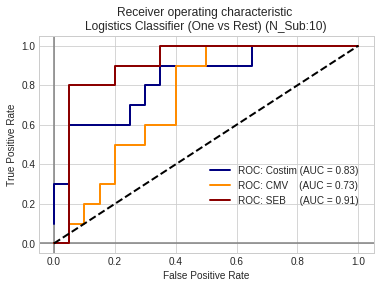

In [15]:
# Compute ROC curve and ROC area for each class
print("STEP: ROC curve")
print("+++++++++++++++++++++++++++++++++++")

### init
fpr, tpr, roc_auc = dict(), dict(), dict()
n_classes = len(dat_img.unique_label())

### get label: test data and predicted
res = pca_logreg.predict(dat_img_test)
y_prob = res['predicted_prob']
y_test = dat_img_test.label
y_test = to_categorical(y_test)

### calculate fpr and tpr
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

#######################################################

### set plot
plt.figure()
lw = 2

### since there is only two classes, below are the same
plt.plot(fpr[0], tpr[0], color='navy',       lw=lw, label='ROC: Costim (AUC = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], color='darkorange', lw=lw, label='ROC: CMV    (AUC = %0.2f)' % roc_auc[1])
plt.plot(fpr[2], tpr[2], color='darkred',    lw=lw, label='ROC: SEB     (AUC = %0.2f)' % roc_auc[2])

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nLogistics Classifier (One vs Rest) (N_Sub:10)')
plt.legend(loc=(0.5, 0.2)) #plt.legend(loc="lower right")

plt.show()

# Perform PCA on the image and apply logistic regression (N10)

In [17]:
wrap_img = wrap_tsne_n10_v01
N_SAMPLE    = 11
N_SUBSAMPLE = 10 

### Kfold CV

In [22]:
kargs = dict(pca_explained_ratio = 0.9)
fprs, tprs, roc_aucs = kfold(wrap_img, Classify_PCA_LogReg, kargs, N_SAMPLE, N_SUBSAMPLE)

kfold: k = 0
	Fit & Predict
	ROC
kfold: k = 1
	Fit & Predict
	ROC
kfold: k = 2
	Fit & Predict
	ROC
kfold: k = 3
	Fit & Predict
	ROC
kfold: k = 4
	Fit & Predict
	ROC
kfold: k = 5
	Fit & Predict
	ROC
kfold: k = 6
	Fit & Predict
	ROC
kfold: k = 7
	Fit & Predict
	ROC
kfold: k = 8
	Fit & Predict
	ROC
kfold: k = 9
	Fit & Predict
	ROC
kfold: k = 10
	Fit & Predict
	ROC


### Evaluating Performance

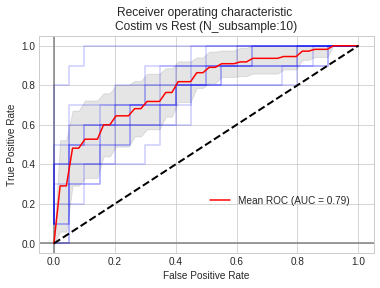

In [30]:
###
idx_class = 0
res_roc = pool_roc(fprs, tprs, idx_class)

###
for k in fprs.keys(): 
    fpr     = fprs[k][idx_class]
    tpr     = tprs[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
###
base_fpr     = res_roc["fpr"]
base_tprs_mu = res_roc["tprs_mu"]
base_tprs_up = res_roc["tprs_upper"]
base_tprs_lw = res_roc["tprs_lower"]
base_auc     = res_roc["auc"]

plt.plot(base_fpr, base_tprs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % base_auc)
plt.fill_between(base_fpr, base_tprs_lw, base_tprs_up, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nCostim vs Rest (N_subsample:' + str(N_SUBSAMPLE) + ')')
plt.legend(loc=(0.5, 0.2))

plt.savefig(os.path.join(FIG_DIR, "eqapol_pipe01_pca_logis_costim_n10.png"), dpi=300)
pass

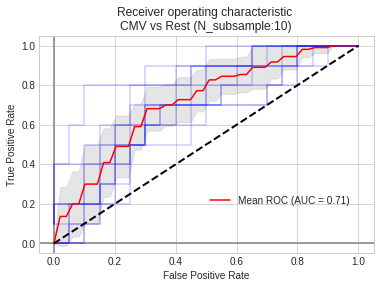

In [31]:
###
idx_class = 1
res_roc = pool_roc(fprs, tprs, idx_class)

###
for k in fprs.keys(): 
    fpr     = fprs[k][idx_class]
    tpr     = tprs[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
###
base_fpr     = res_roc["fpr"]
base_tprs_mu = res_roc["tprs_mu"]
base_tprs_up = res_roc["tprs_upper"]
base_tprs_lw = res_roc["tprs_lower"]
base_auc     = res_roc["auc"]

plt.plot(base_fpr, base_tprs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % base_auc)
plt.fill_between(base_fpr, base_tprs_lw, base_tprs_up, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nCMV vs Rest (N_subsample:' + str(N_SUBSAMPLE) + ')')
plt.legend(loc=(0.5, 0.2)) 

plt.savefig(os.path.join(FIG_DIR, "eqapol_pipe01_pca_logis_cmv_n10.png"), dpi=300)
pass

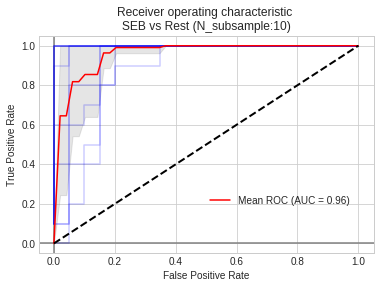

In [32]:
###
idx_class = 2
res_roc = pool_roc(fprs, tprs, idx_class)

###
for k in fprs.keys(): 
    fpr     = fprs[k][idx_class]
    tpr     = tprs[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
###
base_fpr     = res_roc["fpr"]
base_tprs_mu = res_roc["tprs_mu"]
base_tprs_up = res_roc["tprs_upper"]
base_tprs_lw = res_roc["tprs_lower"]
base_auc     = res_roc["auc"]

plt.plot(base_fpr, base_tprs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % base_auc)
plt.fill_between(base_fpr, base_tprs_lw, base_tprs_up, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nSEB vs Rest (N_subsample:' + str(N_SUBSAMPLE) + ')')
plt.legend(loc=(0.5, 0.2)) 

plt.savefig(os.path.join(FIG_DIR, "eqapol_pipe01_pca_logis_seb_n10.png"), dpi=300)
pass

# Perform PCA on the image and apply logistic regression (N50)

In [33]:
wrap_img = wrap_tsne_n50_v01
N_SAMPLE    = 11
N_SUBSAMPLE = 50 

### Kfold CV

In [34]:
kargs = dict(pca_explained_ratio = 0.9)
fprs, tprs, roc_aucs = kfold(wrap_img, Classify_PCA_LogReg, kargs, N_SAMPLE, N_SUBSAMPLE)

kfold: k = 0
	Fit & Predict
	ROC
kfold: k = 1
	Fit & Predict
	ROC
kfold: k = 2
	Fit & Predict
	ROC
kfold: k = 3
	Fit & Predict
	ROC
kfold: k = 4
	Fit & Predict
	ROC
kfold: k = 5
	Fit & Predict
	ROC
kfold: k = 6
	Fit & Predict
	ROC
kfold: k = 7
	Fit & Predict
	ROC
kfold: k = 8
	Fit & Predict
	ROC
kfold: k = 9
	Fit & Predict
	ROC
kfold: k = 10
	Fit & Predict
	ROC


### Evaluating Performance

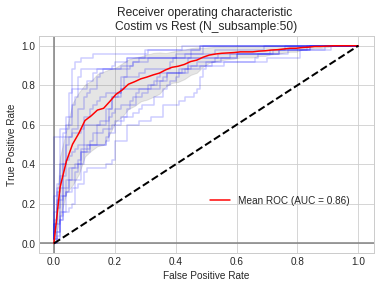

In [38]:
###
idx_class = 0
res_roc = pool_roc(fprs, tprs, idx_class)

###
for k in fprs.keys(): 
    fpr     = fprs[k][idx_class]
    tpr     = tprs[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
###
base_fpr     = res_roc["fpr"]
base_tprs_mu = res_roc["tprs_mu"]
base_tprs_up = res_roc["tprs_upper"]
base_tprs_lw = res_roc["tprs_lower"]
base_auc     = res_roc["auc"]

plt.plot(base_fpr, base_tprs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % base_auc)
plt.fill_between(base_fpr, base_tprs_lw, base_tprs_up, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nCostim vs Rest (N_subsample:' + str(N_SUBSAMPLE) + ')')
plt.legend(loc=(0.5, 0.2))

plt.savefig(os.path.join(FIG_DIR, "eqapol_pipe01_pca_logis_costim_n50.png"), dpi=300)
pass

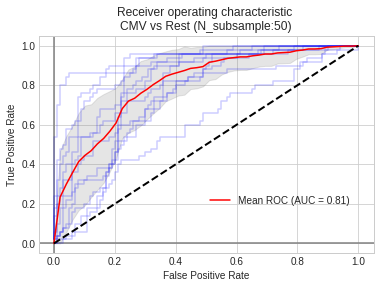

In [39]:
###
idx_class = 1
res_roc = pool_roc(fprs, tprs, idx_class)

###
for k in fprs.keys(): 
    fpr     = fprs[k][idx_class]
    tpr     = tprs[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
###
base_fpr     = res_roc["fpr"]
base_tprs_mu = res_roc["tprs_mu"]
base_tprs_up = res_roc["tprs_upper"]
base_tprs_lw = res_roc["tprs_lower"]
base_auc     = res_roc["auc"]

plt.plot(base_fpr, base_tprs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % base_auc)
plt.fill_between(base_fpr, base_tprs_lw, base_tprs_up, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nCMV vs Rest (N_subsample:' + str(N_SUBSAMPLE) + ')')
plt.legend(loc=(0.5, 0.2)) 

plt.savefig(os.path.join(FIG_DIR, "eqapol_pipe01_pca_logis_cmv_n50.png"), dpi=300)
pass

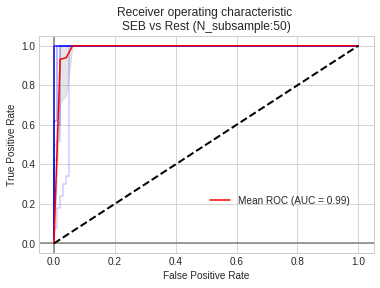

In [40]:
###
idx_class = 2
res_roc = pool_roc(fprs, tprs, idx_class)

###
for k in fprs.keys(): 
    fpr     = fprs[k][idx_class]
    tpr     = tprs[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
###
base_fpr     = res_roc["fpr"]
base_tprs_mu = res_roc["tprs_mu"]
base_tprs_up = res_roc["tprs_upper"]
base_tprs_lw = res_roc["tprs_lower"]
base_auc     = res_roc["auc"]

plt.plot(base_fpr, base_tprs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % base_auc)
plt.fill_between(base_fpr, base_tprs_lw, base_tprs_up, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nSEB vs Rest (N_subsample:' + str(N_SUBSAMPLE) + ')')
plt.legend(loc=(0.5, 0.2)) 

plt.savefig(os.path.join(FIG_DIR, "eqapol_pipe01_pca_logis_seb_n50.png"), dpi=300)
pass

------

# Original Code (Before written into a function)
## Perform PCA on the image and apply logistic regression (N10)

In [30]:
dat_img   = wrap_tsne_n10_v01
n_classes = len(dat_img.unique_label())
FPR, TPR, ROC_AUC = dict(), dict(), dict()

for idx in range(11):
    print("kfold: k =", idx)
    dat_img_train, dat_img_test = leave_one_out_split(dat_img, idx, 11, 10)
    pca_logreg = Classify_PCA_LogReg(dat_img_train, pca_explained_ratio = 0.9)  
    pca_logreg = pca_logreg.fit(dat_img_train, verbose = 0)
    
    print("    Predict")
    res = pca_logreg.predict(dat_img_test)
    y_prob = res['predicted_prob']
    y_test = dat_img_test.label
    y_test = to_categorical(y_test)
    
    ### calculate fpr and tpr
    print("    ROC")
    fpr, tpr, roc_auc = dict(), dict(), dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    FPR[idx]     = fpr
    TPR[idx]     = tpr
    ROC_AUC[idx] = roc_auc

kfold: k = 0
    Predict
    ROC
kfold: k = 1
    Predict
    ROC
kfold: k = 2
    Predict
    ROC
kfold: k = 3
    Predict
    ROC
kfold: k = 4
    Predict
    ROC
kfold: k = 5
    Predict
    ROC
kfold: k = 6
    Predict
    ROC
kfold: k = 7
    Predict
    ROC
kfold: k = 8
    Predict
    ROC
kfold: k = 9
    Predict
    ROC
kfold: k = 10
    Predict
    ROC


# Visualization

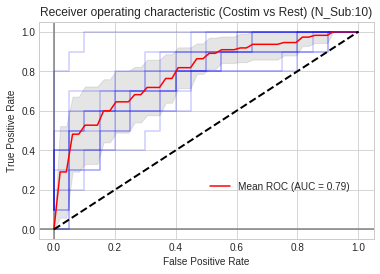

In [64]:
###
idx_class = 0
lw = 2
rocs = list()

###
for k in FPR.keys():
    ###
    base_fpr = np.linspace(0, 1, 50)
    
    ###
    fpr     = FPR[k][idx_class]
    tpr     = TPR[k][idx_class]
    roc_auc = ROC_AUC[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
    ###
    roc = interp(base_fpr, fpr, tpr)
    roc[0] = 0.0
    rocs.append(roc)

###
rocs    = np.array(rocs)
rocs_mu = rocs.mean(axis=0)
rocs_sd = rocs.std(axis=0)    
rocs_upper = np.minimum(rocs_mu + rocs_sd, 1)
rocs_lower = rocs_mu - rocs_sd
roc_auc    = auc(base_fpr, rocs_mu)

###
plt.plot(base_fpr, rocs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % roc_auc)
plt.fill_between(base_fpr, rocs_lower, rocs_upper, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nCostim vs Rest (N_subsample:10)')
plt.legend(loc=(0.5, 0.2)) 
pass

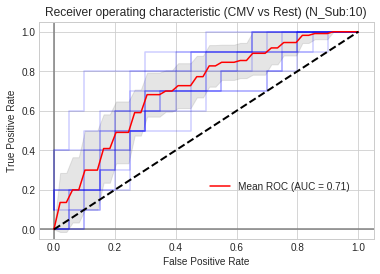

In [65]:
idx_class = 1
lw = 2
rocs = list()

for k in FPR.keys():
    ###
    base_fpr = np.linspace(0, 1, 50)
    
    ###
    fpr     = FPR[k][idx_class]
    tpr     = TPR[k][idx_class]
    roc_auc = ROC_AUC[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
    ###
    roc = interp(base_fpr, fpr, tpr)
    roc[0] = 0.0
    rocs.append(roc)

###
rocs    = np.array(rocs)
rocs_mu = rocs.mean(axis=0)
rocs_sd = rocs.std(axis=0)    
rocs_upper = np.minimum(rocs_mu + rocs_sd, 1)
rocs_lower = rocs_mu - rocs_sd
roc_auc    = auc(base_fpr, rocs_mu)

###
plt.plot(base_fpr, rocs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % roc_auc)
plt.fill_between(base_fpr, rocs_lower, rocs_upper, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nCMV vs Rest (N_subsample:10)')
plt.legend(loc=(0.5, 0.2)) 
pass

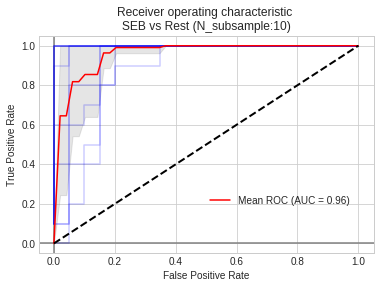

In [67]:
idx_class = 2
lw = 2
rocs = list()

for k in FPR.keys():
    ###
    base_fpr = np.linspace(0, 1, 50)
    
    ###
    fpr     = FPR[k][idx_class]
    tpr     = TPR[k][idx_class]
    roc_auc = ROC_AUC[k][idx_class]
    plt.plot(fpr, tpr, 'b', alpha=0.2)  
    
    ###
    roc = interp(base_fpr, fpr, tpr)
    roc[0] = 0.0
    rocs.append(roc)

###
rocs    = np.array(rocs)
rocs_mu = rocs.mean(axis=0)
rocs_sd = rocs.std(axis=0)    
rocs_upper = np.minimum(rocs_mu + rocs_sd, 1)
rocs_lower = rocs_mu - rocs_sd
roc_auc    = auc(base_fpr, rocs_mu)

###
plt.plot(base_fpr, rocs_mu, 'r', alpha=1, label='Mean ROC (AUC = %0.2f)' % roc_auc)
plt.fill_between(base_fpr, rocs_lower, rocs_upper, color='grey', alpha=0.2)

### visualize ROC curve
plt.plot([0, 1], [0, 1], color='black', lw=lw, linestyle='--')
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.vlines(0, -0.05, 1.05, color = "Gray")
plt.hlines(0, -0.05, 1.05, color = "Gray")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic \nSEB vs Rest (N_subsample:10)')
plt.legend(loc=(0.5, 0.2)) 
pass